# Tech Challenge Fase 3 - Previsão de Casos de Dengue

## 🔧 Notebook 2: Processamento de Dados e Feature Engineering

### 📌 Objetivo
Este notebook aborda as etapas de:
1. **Processamento dos dados**: Limpeza e tratamento
2. **Feature Engineering**: Criação de variáveis lag e médias móveis
3. **Preparação para modelagem**: Divisão dos dados e normalização

### 🎯 Estratégia
- Trabalhar em nível de estado (COD_UF) e período temporal
- Criar features de lag (1, 3, 6 meses) para capturar padrões temporais
- Implementar médias móveis (3, 6, 12 meses) para suavizar tendências
- Adicionar features sazonais e temporais

In [1]:
# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Configurações
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


In [2]:
# Carregamento e preparação inicial dos dados
df = pd.read_csv('dados_dengue_clima_saneamento_2014_2025.csv')

# Extrair ano e mês da coluna periodo
df['data'] = pd.to_datetime(df['periodo'])
df['Ano'] = df['data'].dt.year
df['Mês'] = df['data'].dt.month
df = df.sort_values(['COD_UF', 'data']).reset_index(drop=True)

print(f"📊 Dados carregados: {df.shape}")
print(f"📅 Período: {df['data'].min().strftime('%Y-%m')} até {df['data'].max().strftime('%Y-%m')}")
print(f"🗺️ Estados únicos: {df['COD_UF'].nunique()}")

# Verificar continuidade temporal
print(f"\n🔍 Verificando continuidade temporal por estado:")
for estado in df['COD_UF'].unique()[:5]:  # Mostra apenas os primeiros 5
    dados_estado = df[df['COD_UF'] == estado]
    meses_esperados = (dados_estado['data'].max() - dados_estado['data'].min()).days // 30 + 1
    meses_reais = len(dados_estado)
    print(f"   {estado}: {meses_reais} registros (esperado ~{meses_esperados})")

📊 Dados carregados: (3584, 23)
📅 Período: 2014-01 até 2025-02
🗺️ Estados únicos: 27

🔍 Verificando continuidade temporal por estado:
   AC: 133 registros (esperado ~135)
   AL: 133 registros (esperado ~135)
   AM: 133 registros (esperado ~135)
   AP: 133 registros (esperado ~135)
   BA: 133 registros (esperado ~135)


## 🔨 Feature Engineering - Criação de Variáveis Temporais

In [3]:
def criar_features_temporais(df):
    """
    Cria features temporais e de lag para cada estado
    """
    df_features = df.copy()

    # Features de tempo
    df_features['trimestre'] = df_features['Mês'].apply(lambda x: (x-1)//3 + 1)
    df_features['semestre'] = df_features['Mês'].apply(lambda x: 1 if x <= 6 else 2)
    df_features['estacao'] = df_features['Mês'].apply(
        lambda x: 'Verão' if x in [12, 1, 2] else
                  'Outono' if x in [3, 4, 5] else
                  'Inverno' if x in [6, 7, 8] else 'Primavera'
    )

    # Encoder para estação
    le = LabelEncoder()
    df_features['estacao_encoded'] = le.fit_transform(df_features['estacao'])

    # Encoder para estados
    df_features['estado_encoded'] = LabelEncoder().fit_transform(df_features['COD_UF'])

    results = []

    for estado in df_features['COD_UF'].unique():
        dados_estado = df_features[df_features['COD_UF'] == estado].copy()
        dados_estado = dados_estado.sort_values('data')

        # Features de lag (casos anteriores)
        for lag in [1, 2, 3, 6]:
            dados_estado[f'casos_lag_{lag}'] = dados_estado['Quantidade de Casos'].shift(lag)

        # Médias móveis
        for janela in [3, 6, 12]:
            dados_estado[f'casos_ma_{janela}'] = dados_estado['Quantidade de Casos'].rolling(
                window=janela, min_periods=1
            ).mean()

        # Features climáticas com lag
        for lag in [1, 2]:
            dados_estado[f'temp_max_lag_{lag}'] = dados_estado['temp_max_media_mensal_uf'].shift(lag)
            dados_estado[f'precipitacao_lag_{lag}'] = dados_estado['precipitacao_media_mensal_uf'].shift(lag)
            dados_estado[f'umidade_max_lag_{lag}'] = dados_estado['umidade_max_media_mensal_uf'].shift(lag)

        results.append(dados_estado)

    return pd.concat(results, ignore_index=True)

# Aplicar feature engineering
print("🔄 Criando features temporais e de lag...")
df_features = criar_features_temporais(df)

print(f"✅ Features criadas! Dimensões: {df_features.shape}")
print(f"📊 Novas colunas: {df_features.shape[1] - df.shape[1]} adicionadas")

# Mostrar as novas features
novas_features = [col for col in df_features.columns if col not in df.columns]
print(f"\n🆕 Novas features:")
for feature in novas_features:
    print(f"   • {feature}")

🔄 Criando features temporais e de lag...
✅ Features criadas! Dimensões: (3584, 41)
📊 Novas colunas: 18 adicionadas

🆕 Novas features:
   • trimestre
   • semestre
   • estacao
   • estacao_encoded
   • estado_encoded
   • casos_lag_1
   • casos_lag_2
   • casos_lag_3
   • casos_lag_6
   • casos_ma_3
   • casos_ma_6
   • casos_ma_12
   • temp_max_lag_1
   • precipitacao_lag_1
   • umidade_max_lag_1
   • temp_max_lag_2
   • precipitacao_lag_2
   • umidade_max_lag_2


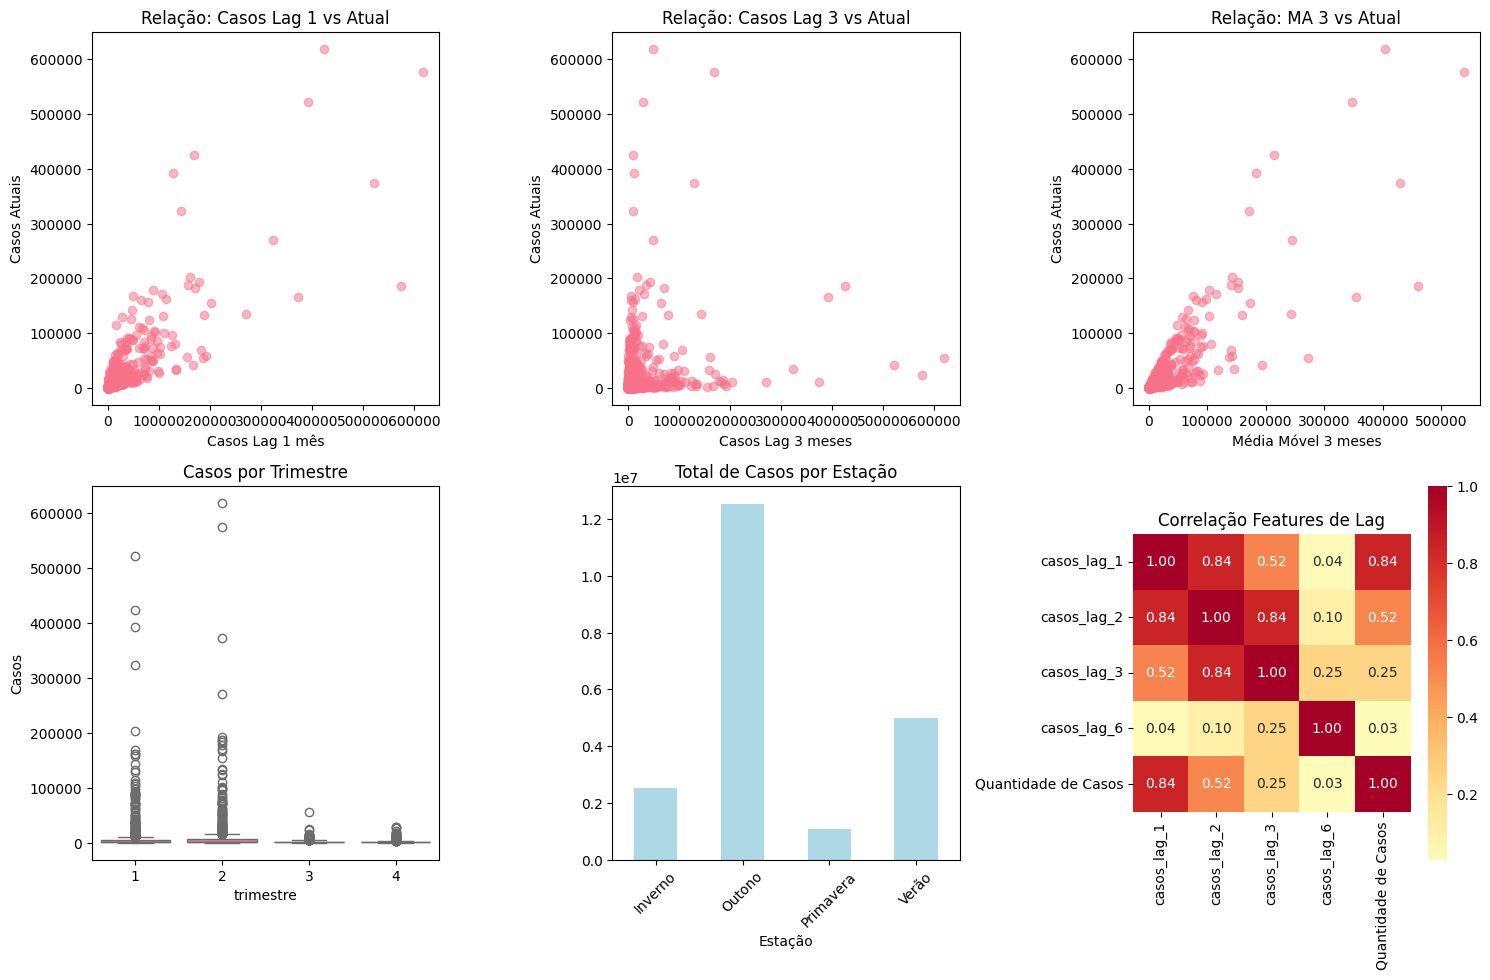

In [4]:
# Análise das novas features criadas
plt.figure(figsize=(15, 10))

# Lag features vs casos atuais
plt.subplot(2, 3, 1)
plt.scatter(df_features['casos_lag_1'], df_features['Quantidade de Casos'], alpha=0.5)
plt.xlabel('Casos Lag 1 mês')
plt.ylabel('Casos Atuais')
plt.title('Relação: Casos Lag 1 vs Atual')

plt.subplot(2, 3, 2)
plt.scatter(df_features['casos_lag_3'], df_features['Quantidade de Casos'], alpha=0.5)
plt.xlabel('Casos Lag 3 meses')
plt.ylabel('Casos Atuais')
plt.title('Relação: Casos Lag 3 vs Atual')

# Médias móveis vs casos atuais
plt.subplot(2, 3, 3)
plt.scatter(df_features['casos_ma_3'], df_features['Quantidade de Casos'], alpha=0.5)
plt.xlabel('Média Móvel 3 meses')
plt.ylabel('Casos Atuais')
plt.title('Relação: MA 3 vs Atual')

# Distribuição por trimestre
plt.subplot(2, 3, 4)
sns.boxplot(data=df_features, x='trimestre', y='Quantidade de Casos')
plt.title('Casos por Trimestre')
plt.ylabel('Casos')

# Distribuição por estação
plt.subplot(2, 3, 5)
casos_por_estacao = df_features.groupby('estacao')['Quantidade de Casos'].sum()
casos_por_estacao.plot(kind='bar', color='lightblue')
plt.title('Total de Casos por Estação')
plt.xlabel('Estação')
plt.xticks(rotation=45)

# Correlação das features de lag
plt.subplot(2, 3, 6)
lag_features = ['casos_lag_1', 'casos_lag_2', 'casos_lag_3', 'casos_lag_6']
corr_lag = df_features[lag_features + ['Quantidade de Casos']].corr()
sns.heatmap(corr_lag, annot=True, cmap='RdYlBu_r', center=0, square=True, fmt='.2f')
plt.title('Correlação Features de Lag')

plt.tight_layout()
plt.show()

## 📊 Preparação dos Dados para Modelagem

In [5]:
# Seleção das features para modelagem
features_para_modelo = [
    # Features temporais
    'Mês', 'trimestre', 'semestre', 'estacao_encoded', 'estado_encoded',

    # Features climáticas
    'precipitacao_media_mensal_uf', 'temp_max_media_mensal_uf', 'temp_min_media_mensal_uf',
    'umidade_max_media_mensal_uf', 'umidade_min_media_mensal_uf',
    'pressao_max_media_mensal_uf', 'pressao_min_media_mensal_uf',

    # Features de saneamento e população
    'Densidade demográfica (pessoas por km²) (Pessoas por km²) (IBGE)',
    'População total (pessoas) (IBGE)',
    'Despesas per capita das famílias com saneamento, em R$ a preços de 2024 (deflator IPCA, item água e esgoto) (R$ per capita a preços de 2024) (SINISA)',

    # Features de lag
    'casos_lag_1', 'casos_lag_2', 'casos_lag_3', 'casos_lag_6',

    # Médias móveis
    'casos_ma_3', 'casos_ma_6', 'casos_ma_12',

    # Features climáticas com lag
    'temp_max_lag_1', 'precipitacao_lag_1', 'umidade_max_lag_1',
    'temp_max_lag_2', 'precipitacao_lag_2', 'umidade_max_lag_2'
]

# Variável alvo
target = 'Quantidade de Casos'

# Remover linhas com NaN (principalmente dos lags)
df_modelo = df_features[features_para_modelo + [target]].dropna()

print(f"📊 Dados para modelagem:")
print(f"   • Registros: {df_modelo.shape[0]:,}")
print(f"   • Features: {df_modelo.shape[1] - 1}")  # -1 para não contar o target
print(f"   • Valores removidos (NaN): {df_features.shape[0] - df_modelo.shape[0]:,}")

# Verificar distribuição temporal após limpeza
data_modelo = df_features.loc[df_modelo.index, 'data']
print(f"   • Período final: {data_modelo.min().strftime('%Y-%m')} até {data_modelo.max().strftime('%Y-%m')}")

# Estatísticas da variável alvo
print(f"\n🎯 Estatísticas da variável alvo:")
print(df_modelo[target].describe())

📊 Dados para modelagem:
   • Registros: 2,991
   • Features: 28
   • Valores removidos (NaN): 593
   • Período final: 2014-07 até 2023-12

🎯 Estatísticas da variável alvo:
count      2991.000000
mean       4534.658977
std       15618.419226
min           1.000000
25%         311.000000
50%         901.000000
75%        2999.500000
max      322982.000000
Name: Quantidade de Casos, dtype: float64


In [7]:
# Divisão dos dados: Temporal (2014-2022 treino, 2023-2025 teste)
df_modelo_com_data = df_features.loc[df_modelo.index].copy()
df_modelo_com_data = df_modelo_com_data.reset_index(drop=True)

# Definir data de corte
data_corte = pd.to_datetime('2023-01-01')
mask_treino = df_modelo_com_data['data'] < data_corte
mask_teste = df_modelo_com_data['data'] >= data_corte

# Separar features e target (reset index para alinhar com as máscaras)
X = df_modelo[features_para_modelo].reset_index(drop=True)
y = df_modelo[target].reset_index(drop=True)

# Divisão temporal
X_train = X[mask_treino]
X_test = X[mask_teste]
y_train = y[mask_treino]
y_test = y[mask_teste]

print(f"📈 Divisão dos dados:")
print(f"   • Treino: {X_train.shape[0]:,} registros ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   • Teste:  {X_test.shape[0]:,} registros ({X_test.shape[0]/len(X)*100:.1f}%)")

# Verificar distribuição temporal
data_treino = df_modelo_com_data.loc[X_train.index, 'data']
data_teste = df_modelo_com_data.loc[X_test.index, 'data']
print(f"   • Período treino: {data_treino.min().strftime('%Y-%m')} até {data_treino.max().strftime('%Y-%m')}")
print(f"   • Período teste:  {data_teste.min().strftime('%Y-%m')} até {data_teste.max().strftime('%Y-%m')}")

# Normalização das features numéricas
features_numericas = X_train.select_dtypes(include=[np.number]).columns
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[features_numericas] = scaler.fit_transform(X_train[features_numericas])
X_test_scaled[features_numericas] = scaler.transform(X_test[features_numericas])

print(f"\n🔧 Normalização aplicada a {len(features_numericas)} features numéricas")

📈 Divisão dos dados:
   • Treino: 2,678 registros (89.5%)
   • Teste:  313 registros (10.5%)
   • Período treino: 2014-07 até 2022-12
   • Período teste:  2023-01 até 2023-12

🔧 Normalização aplicada a 28 features numéricas


In [8]:
# Salvar dados processados
import pickle

# Dados para salvar
dados_processados = {
    'X_train': X_train_scaled,
    'X_test': X_test_scaled,
    'y_train': y_train,
    'y_test': y_test,
    'features_para_modelo': features_para_modelo,
    'scaler': scaler,
    'data_treino': data_treino,
    'data_teste': data_teste
}

# Salvar
with open('dados_processados.pkl', 'wb') as f:
    pickle.dump(dados_processados, f)

print("💾 Dados processados salvos em 'dados_processados.pkl'")

# Resumo final das correlações mais importantes
print(f"\n🔍 Top 10 correlações com a variável alvo:")
correlacoes_target = df_modelo.corr()[target].abs().sort_values(ascending=False)
for i, (feature, corr) in enumerate(correlacoes_target.head(11).items(), 1):  # 11 para pular o próprio target
    if feature != target:
        print(f"   {i-1}. {feature}: {corr:.3f}")

💾 Dados processados salvos em 'dados_processados.pkl'

🔍 Top 10 correlações com a variável alvo:
   1. casos_ma_3: 0.867
   2. casos_lag_1: 0.837
   3. casos_ma_6: 0.609
   4. casos_ma_12: 0.560
   5. casos_lag_2: 0.519
   6. População total (pessoas) (IBGE): 0.418
   7. casos_lag_3: 0.257
   8. pressao_max_media_mensal_uf: 0.230
   9. pressao_min_media_mensal_uf: 0.230
   10. semestre: 0.201


## ✅ Resumo do Processamento

**Features Criadas:**
- ✅ **Temporais**: trimestre, semestre, estação, encodings
- ✅ **Lag**: casos anteriores (1, 2, 3, 6 meses)
- ✅ **Médias móveis**: suavização temporal (3, 6, 12 meses)
- ✅ **Climáticas com lag**: temperatura, precipitação, umidade

**Preparação para Modelagem:**
- ✅ **Divisão temporal**: 2014-2022 (treino) vs 2023-2025 (teste)
- ✅ **Normalização**: StandardScaler aplicado às features numéricas
- ✅ **Limpeza**: Remoção de registros com NaN das features de lag

**Próximos Passos:**
1. Desenvolvimento e treinamento dos modelos
2. Otimização de hiperparâmetros
3. Avaliação e comparação dos modelos

**Arquivo salvo**: `dados_processados.pkl` - pronto para modelagem!

## 🔍 Explicação: fit_transform() vs transform()

### 📚 **Conceitos Fundamentais:**

**`fit_transform()`**: 
- Combina `fit()` + `transform()`
- Aprende os parâmetros dos dados E aplica a transformação
- Usado apenas nos **dados de treino**

**`transform()`**: 
- Apenas aplica a transformação usando parâmetros já aprendidos
- Usado nos **dados de teste/validação**
- Evita data leakage

### ⚠️ **Regra de Ouro:**
- ✅ `fit_transform()` → Apenas no conjunto de **treino**
- ✅ `transform()` → No conjunto de **teste**
- ❌ Nunca usar `fit_transform()` nos dados de teste!

In [ ]:
# Demonstração prática: fit_transform() vs transform()
import numpy as np
from sklearn.preprocessing import StandardScaler

# Exemplo simples para demonstrar a diferença
print("🎯 Demonstração: fit_transform() vs transform()")
print("=" * 50)

# Dados de exemplo
dados_treino = np.array([[1, 2], [3, 4], [5, 6]])
dados_teste = np.array([[7, 8], [9, 10]])

print("📊 Dados originais:")
print(f"Treino: {dados_treino}")
print(f"Teste:  {dados_teste}")

# Criar scaler
scaler = StandardScaler()

# 1. fit_transform() no treino (aprende parâmetros + transforma)
treino_scaled = scaler.fit_transform(dados_treino)
print(f"\n🔧 Após fit_transform() no treino:")
print(f"Média aprendida: {scaler.mean_}")
print(f"Desvio aprendido: {scaler.scale_}")
print(f"Treino normalizado: {treino_scaled}")

# 2. transform() no teste (apenas aplica parâmetros aprendidos)
teste_scaled = scaler.transform(dados_teste)
print(f"\n✅ Após transform() no teste:")
print(f"Teste normalizado: {teste_scaled}")

print(f"\n💡 Observe:")
print(f"   • O scaler aprendeu média={scaler.mean_} e desvio={scaler.scale_} do TREINO")
print(f"   • Os mesmos parâmetros foram aplicados no TESTE")
print(f"   • Isso evita data leakage!")

# ❌ Exemplo do que NÃO fazer (apenas para demonstração)
print(f"\n❌ Exemplo ERRADO (data leakage):")
todos_dados = np.vstack([dados_treino, dados_teste])
scaler_errado = StandardScaler()
todos_scaled = scaler_errado.fit_transform(todos_dados)
print(f"Média com data leakage: {scaler_errado.mean_}")
print(f"Desvio com data leakage: {scaler_errado.scale_}")
print(f"Diferença na média: {abs(scaler.mean_[0] - scaler_errado.mean_[0]):.3f}")